<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/01_uci_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Upload dataset to Colab
from google.colab import files
uploaded = files.upload()  # Select spam.csv file here

Saving spam.csv to spam.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv('spam.csv', encoding='latin-1', sep='\t', header=None, names=['label', 'message'])
print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [6]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
label      0
message    0
dtype: int64

Duplicate rows: 403


In [7]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Shape after removing duplicates: (5169, 2)
Duplicate rows remaining: 0


Class Distribution:
label
ham     4516
spam     653
Name: count, dtype: int64

Spam percentage: 12.63 %
Ham percentage: 87.37 %


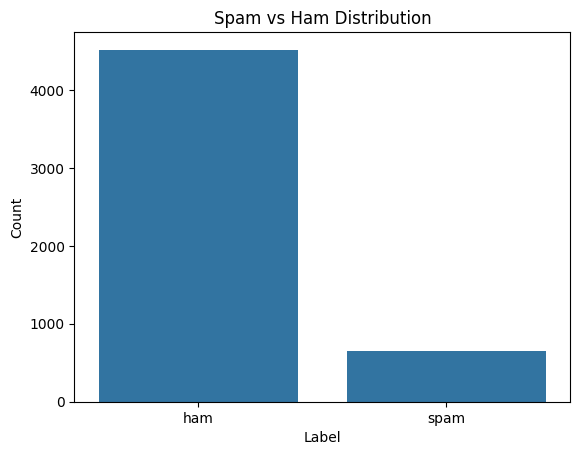

In [8]:
print("Class Distribution:")
print(df['label'].value_counts())
print("\nSpam percentage:", round(df[df['label']=='spam'].shape[0] / df.shape[0] * 100, 2), "%")
print("Ham percentage:", round(df[df['label']=='ham'].shape[0] / df.shape[0] * 100, 2), "%")

# Plot
sns.countplot(x='label', data=df)
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.savefig('class_distribution.png')
plt.show()

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.987600  56.736845   2.0   34.0   53.0   91.0  910.0
spam    653.0  138.130168  29.937254  13.0  132.0  149.0  157.0  224.0


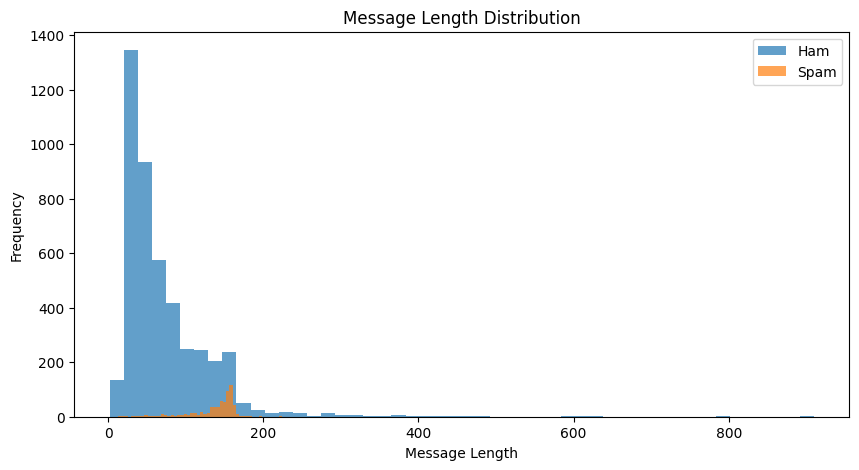

In [9]:
df['message_length'] = df['message'].apply(len)

print(df.groupby('label')['message_length'].describe())

# Plot
plt.figure(figsize=(10,5))
df[df['label']=='ham']['message_length'].plot(bins=50, kind='hist', label='Ham', alpha=0.7)
df[df['label']=='spam']['message_length'].plot(bins=50, kind='hist', label='Spam', alpha=0.7)
plt.legend()
plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.savefig('message_length_distribution.png')
plt.show()

In [10]:
import json

uci_stats = {
    'total': int(df.shape[0]),
    'ham_count': int(df[df['label']=='ham'].shape[0]),
    'spam_count': int(df[df['label']=='spam'].shape[0]),
    'ham_pct': round(df[df['label']=='ham'].shape[0]/df.shape[0]*100, 2),
    'spam_pct': round(df[df['label']=='spam'].shape[0]/df.shape[0]*100, 2),
    'avg_ham_length': round(df[df['label']=='ham']['message_length'].mean()),
    'avg_spam_length': round(df[df['label']=='spam']['message_length'].mean()),
    'html_tags': 'None',
    'headers': 'None',
    'content': 'Body only',
    'domain': 'SMS'
}

with open('uci_stats.json', 'w') as f:
    json.dump(uci_stats, f)

print("UCI stats saved!")
print(uci_stats)

UCI stats saved!
{'total': 5169, 'ham_count': 4516, 'spam_count': 653, 'ham_pct': 87.37, 'spam_pct': 12.63, 'avg_ham_length': 71, 'avg_spam_length': 138, 'html_tags': 'None', 'headers': 'None', 'content': 'Body only', 'domain': 'SMS'}
